# Пошаговое тестирование каждой функции модуля data

## Настройка окружения


In [8]:
import sys
from pathlib import Path

# Добавляем корень проекта в PYTHONPATH
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(f"Корень проекта: {PROJECT_ROOT}")

Корень проекта: D:\Projects\PythonProject\music-genre-classification-fma


In [9]:
import pandas as pd
import numpy as np

# Настройки для отображения
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)

## Тестирование конфигурации и путей

In [10]:
from src.data.config import paths, audio_params, PROJECT_ROOT as SRC_ROOT

print("=== Тест 1: Конфигурация ===")
print(f"PROJECT_ROOT: {SRC_ROOT}")
print(f"\npaths.metadata_dir: {paths.metadata_dir}")
print(f"paths.active_zip: {paths.active_zip}")
print(f"paths.active_subset: {paths.active_subset}")

=== Тест 1: Конфигурация ===
PROJECT_ROOT: D:\Projects\PythonProject\music-genre-classification-fma

paths.metadata_dir: E:\music-genre-classifier\fma_metadata
paths.active_zip: E:\music-genre-classifier\fma_medium.zip
paths.active_subset: medium


In [11]:
print("=== Тест 2: Существование файлов ===")
tracks_path = paths.get_tracks_csv()
features_path = paths.get_features_csv()
genres_path = paths.get_genres_csv()

print(f"tracks.csv: {tracks_path}")
print(f"  Существует: {tracks_path.exists()}")
print(f"  Размер: {tracks_path.stat().st_size / 1024 / 1024:.2f} MB" if tracks_path.exists() else "  Файл не найден")

print(f"\nfeatures.csv: {features_path}")
print(f"  Существует: {features_path.exists()}")
print(f"  Размер: {features_path.stat().st_size / 1024 / 1024:.2f} MB" if features_path.exists() else "  Файл не найден")

print(f"\ngenres.csv: {genres_path}")
print(f"  Существует: {genres_path.exists()}")

=== Тест 2: Существование файлов ===
tracks.csv: E:\music-genre-classifier\fma_metadata\tracks.csv
  Существует: True
  Размер: 248.35 MB

features.csv: E:\music-genre-classifier\fma_metadata\features.csv
  Существует: True
  Размер: 907.06 MB

genres.csv: E:\music-genre-classifier\fma_metadata\genres.csv
  Существует: True


In [12]:
print("=== Тест 3: Аудио параметры ===")
print(f"sample_rate: {audio_params.sample_rate}")
print(f"duration: {audio_params.duration} sec")
print(f"n_mels: {audio_params.n_mels}")
print(f"n_mfcc: {audio_params.n_mfcc}")
print(f"hop_length: {audio_params.hop_length}")

=== Тест 3: Аудио параметры ===
sample_rate: 22050
duration: 30 sec
n_mels: 128
n_mfcc: 20
hop_length: 512


## Тестирование загрузчика FMALoader

In [13]:
from src.data.loader import FMALoader

print("=== Тест 4: Инициализация FMALoader ===")
loader = FMALoader()
print(f"loader.metadata_dir: {loader.metadata_dir}")

=== Тест 4: Инициализация FMALoader ===
loader.metadata_dir: E:\music-genre-classifier\fma_metadata


In [14]:
print("=== Тест 5: Загрузка tracks.csv ===")
try:
    tracks = loader.tracks
    print(f"✅ tracks загружен: {tracks.shape}")
    print(f"Индекс: {tracks.index.name}")
    print(f"Колонки (первые 5): {list(tracks.columns[:5])}")
    print(f"Тип мультииндекса: {tracks.columns.nlevels} уровня")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 5: Загрузка tracks.csv ===
Загружено tracks: (106574, 52)
✅ tracks загружен: (106574, 52)
Индекс: track_id
Колонки (первые 5): [('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites')]
Тип мультииндекса: 2 уровня


In [15]:
print("=== Тест 5.1: Структура колонок ===")
for level in tracks.columns.levels:
    print(f"  Уровень '{level}':")
    print(f"    Значения: {list(level)}")

=== Тест 5.1: Структура колонок ===
  Уровень 'Index(['album', 'artist', 'set', 'track'], dtype='str')':
    Значения: ['album', 'artist', 'set', 'track']
  Уровень 'Index(['active_year_begin', 'active_year_end', 'associated_labels', 'bio',
       'bit_rate', 'comments', 'composer', 'date_created', 'date_recorded',
       'date_released', 'duration', 'engineer', 'favorites', 'genre_top',
       'genres', 'genres_all', 'id', 'information', 'interest',
       'language_code', 'latitude', 'license', 'listens', 'location',
       'longitude', 'lyricist', 'members', 'name', 'number', 'producer',
       'publisher', 'related_projects', 'split', 'subset', 'tags', 'title',
       'tracks', 'type', 'website', 'wikipedia_page'],
      dtype='str')':
    Значения: ['active_year_begin', 'active_year_end', 'associated_labels', 'bio', 'bit_rate', 'comments', 'composer', 'date_created', 'date_recorded', 'date_released', 'duration', 'engineer', 'favorites', 'genre_top', 'genres', 'genres_all', 'id', '

In [16]:
print("=== Тест 5.2: Доступ к колонкам ===")
try:
    genre_col = tracks['track', 'genre_top']
    print(f"✅ Доступ к genre_top: первые 5 значений:\n{genre_col.head(5)}")
except KeyError as e:
    print(f"❌ Ошибка доступа: {e}")
    print("Попробуем альтернативный доступ...")
    try:
        genre_col = tracks['track']['genre_top']
        print(f"✅ Альтернативный доступ работает:\n{genre_col.head(5)}")
    except Exception as e2:
        print(f"❌ Альтернативный тоже не работает: {e2}")

=== Тест 5.2: Доступ к колонкам ===
✅ Доступ к genre_top: первые 5 значений:
track_id
2     Hip-Hop
3     Hip-Hop
5     Hip-Hop
10        Pop
20        NaN
Name: (track, genre_top), dtype: str


In [17]:
print("=== Тест 6: Загрузка features.csv ===")
try:
    features = loader.features
    print(f"✅ features загружены: {features.shape}")
    print(f"Колонки (первые 5): {list(features.columns[:5])}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 6: Загрузка features.csv ===
Загружено features: (106574, 518)
✅ features загружены: (106574, 518)
Колонки (первые 5): [('chroma_cens', 'kurtosis', '01'), ('chroma_cens', 'kurtosis', '02'), ('chroma_cens', 'kurtosis', '03'), ('chroma_cens', 'kurtosis', '04'), ('chroma_cens', 'kurtosis', '05')]


In [18]:
print("=== Тест 7: Загрузка genres.csv ===")
try:
    genres = loader.genres
    print(f"✅ genres загружены: {genres.shape}")
    print(f"genres.head():\n{genres.head()}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 7: Загрузка genres.csv ===
Загружено genres: (163, 4)
✅ genres загружены: (163, 4)
genres.head():
          #tracks  parent          title  top_level
genre_id                                           
1            8693      38    Avant-Garde         38
2            5271       0  International          2
3            1752       0          Blues          3
4            4126       0           Jazz          4
5            4106       0      Classical          5


In [19]:
print("=== Тест 8: Фильтрация по подмножеству ===")
try:
    medium_tracks = loader.get_tracks_by_subset('medium')
    print(f"✅ Треков в Medium: {len(medium_tracks)}")

    # Проверяем все ли треки из Medium
    subsets = medium_tracks['set', 'subset'].unique()
    print(f"Уникальные подмножества: {subsets}")
    assert len(subsets) == 1 and subsets[0] == 'medium', "Не все треки из Medium!"
    print("✅ Проверка пройдена: все треки из Medium")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 8: Фильтрация по подмножеству ===
Треков в medium: 25000
✅ Треков в Medium: 25000
Уникальные подмножества: <StringArray>
['small', 'medium']
Length: 2, dtype: str
❌ Ошибка: Не все треки из Medium!


In [20]:
print("=== Тест 9: Доступные подмножества ===")
try:
    all_subsets = loader.tracks['set', 'subset'].unique()
    print(f"Доступные подмножества в данных: {all_subsets}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 9: Доступные подмножества ===
Доступные подмножества в данных: <StringArray>
['small', 'medium', 'large']
Length: 3, dtype: str


In [21]:
print("=== Тест 10: Получение разбиения train/val/test ===")
try:
    splits = loader.get_available_splits(medium_tracks)
    print(f"✅ Разбиение получено:")
    print(f"  training: {len(splits['training'])} треков")
    print(f"  validation: {len(splits['validation'])} треков")
    print(f"  test: {len(splits['test'])} треков")

    total = sum(len(v) for v in splits.values())
    print(f"  Всего: {total} ({total/len(medium_tracks)*100:.1f}% от всех)")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 10: Получение разбиения train/val/test ===
✅ Разбиение получено:
  training: 19922 треков
  validation: 2505 треков
  test: 2573 треков
  Всего: 25000 (100.0% от всех)


In [22]:
print("=== Тест 11: Маппинг жанров ===")
try:
    genre_mapping = loader.get_genre_mapping()
    print(f"✅ Жанров в маппинге: {len(genre_mapping)}")
    print(f"Примеры: {dict(list(genre_mapping.items())[:5])}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 11: Маппинг жанров ===
✅ Жанров в маппинге: 163
Примеры: {1: 'Avant-Garde', 2: 'International', 3: 'Blues', 4: 'Jazz', 5: 'Classical'}


## Тестирование препроцессора

In [24]:
from src.data.preprocessor import DataPreprocessor

print("=== Тест 12: Инициализация препроцессора ===")
preprocessor = DataPreprocessor(min_samples_per_genre=10)
print(f"✅ Препроцессор создан")
print(f"  min_samples_per_genre: {preprocessor.min_samples_per_genre}")

=== Тест 12: Инициализация препроцессора ===
✅ Препроцессор создан
  min_samples_per_genre: 10


In [25]:
print("=== Тест 13: Фильтрация редких жанров ===")

genre_col = ('track', 'genre_top')
genre_counts = medium_tracks[genre_col].value_counts()
print(f"Жанров до фильтрации: {len(genre_counts)}")
print(f"Треков до фильтрации: {len(medium_tracks)}")

=== Тест 13: Фильтрация редких жанров ===
Жанров до фильтрации: 16
Треков до фильтрации: 25000


In [26]:
print("=== Тест 13: Фильтрация редких жанров ===")

genre_col = ('track', 'genre_top')
genre_counts = medium_tracks[genre_col].value_counts()
print(f"Жанров до фильтрации: {len(genre_counts)}")
print(f"Треков до фильтрации: {len(medium_tracks)}")

filtered_tracks = preprocessor.filter_rare_genres(medium_tracks, genre_col)
print(f"\nЖанров после фильтрации: {len(filtered_tracks[genre_col].value_counts())}")
print(f"Треков после фильтрации: {len(filtered_tracks)}")

=== Тест 13: Фильтрация редких жанров ===
Жанров до фильтрации: 16
Треков до фильтрации: 25000
Осталось жанров: 16
Осталось треков: 25000

Жанров после фильтрации: 16
Треков после фильтрации: 25000


In [27]:
print("=== Тест 14: Кодирование меток ===")

test_tracks = filtered_tracks.copy()
genre_col = ('track', 'genre_top')

train_mask = test_tracks['set', 'split'] == 'training'
val_mask = test_tracks['set', 'split'] == 'validation'
test_mask = test_tracks['set', 'split'] == 'test'

y_train = test_tracks[train_mask][genre_col]
y_val = test_tracks[val_mask][genre_col]
y_test = test_tracks[test_mask][genre_col]

print(f"y_train size: {len(y_train)}, y_val: {len(y_val)}, y_test: {len(y_test)}")

try:
    y_train_enc, y_val_enc, y_test_enc = preprocessor.encode_labels(y_train, y_val, y_test)
    print(f"✅ Кодирование выполнено")
    print(f"  Классов: {len(preprocessor.label_encoder.classes_)}")
    print(f"  Пример соответствия: {dict(zip(preprocessor.label_encoder.classes_, range(len(preprocessor.label_encoder.classes_))))}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 14: Кодирование меток ===
y_train size: 19922, y_val: 2505, y_test: 2573
Закодировано классов: 16
  0: Blues
  1: Classical
  2: Country
  3: Easy Listening
  4: Electronic
  5: Experimental
  6: Folk
  7: Hip-Hop
  8: Instrumental
  9: International
  10: Jazz
  11: Old-Time / Historic
  12: Pop
  13: Rock
  14: Soul-RnB
  15: Spoken
✅ Кодирование выполнено
  Классов: 16
  Пример соответствия: {'Blues': 0, 'Classical': 1, 'Country': 2, 'Easy Listening': 3, 'Electronic': 4, 'Experimental': 5, 'Folk': 6, 'Hip-Hop': 7, 'Instrumental': 8, 'International': 9, 'Jazz': 10, 'Old-Time / Historic': 11, 'Pop': 12, 'Rock': 13, 'Soul-RnB': 14, 'Spoken': 15}


In [28]:
print("=== Тест 15: Нормализация признаков ===")

common_ids = test_tracks.index.intersection(features.index)
X = features.loc[common_ids]

X_train_raw = X.loc[test_tracks[train_mask].index]
X_val_raw = X.loc[test_tracks[val_mask].index]
X_test_raw = X.loc[test_tracks[test_mask].index]

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_val shape: {X_val_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")

try:
    X_train_scaled, X_val_scaled, X_test_scaled = preprocessor.normalize_features(
        X_train_raw, X_val_raw, X_test_raw
    )
    print(f"✅ Нормализация выполнена")
    print(f"  X_train: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
    print(f"  X_val:   mean={X_val_scaled.mean():.4f}, std={X_val_scaled.std():.4f}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 15: Нормализация признаков ===
X_train shape: (19922, 518)
X_val shape: (2505, 518)
X_test shape: (2573, 518)
X_train: mean=0.0000, std=1.0000
X_val:   mean=0.0061, std=1.0880
X_test:  mean=-0.0076, std=1.0104
✅ Нормализация выполнена
  X_train: mean=0.0000, std=1.0000
  X_val:   mean=0.0061, std=1.0880


In [29]:
print("=== Тест 16: Веса классов ===")
try:
    weights = preprocessor.get_class_weights(y_train_enc)
    print(f"✅ Веса классов вычислены")
    print(f"  Веса: {weights}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 16: Веса классов ===
✅ Веса классов вычислены
  Веса: {np.int64(0): np.float64(21.467672413793103), np.int64(1): np.float64(2.5154040404040403), np.int64(2): np.float64(8.768485915492958), np.int64(3): np.float64(95.77884615384616), np.int64(4): np.float64(0.24655940594059406), np.int64(5): np.float64(0.6913520266518601), np.int64(6): np.float64(1.0247942386831275), np.int64(7): np.float64(0.7070556501987507), np.int64(8): np.float64(1.1915071770334928), np.int64(9): np.float64(1.5296375921375922), np.int64(10): np.float64(4.069035947712418), np.int64(11): np.float64(3.0517769607843137), np.int64(12): np.float64(1.3175925925925926), np.int64(13): np.float64(0.21917356099278296), np.int64(14): np.float64(13.246010638297872), np.int64(15): np.float64(13.246010638297872)}


In [30]:
print("=== Тест 17: Сохранение препроцессора ===")
save_path = paths.processed_data_dir / 'test_preprocessor.pkl'
try:
    preprocessor.save(save_path)
    print(f"✅ Препроцессор сохранён: {save_path}")
    print(f"  Файл существует: {save_path.exists()}")
    print(f"  Размер: {save_path.stat().st_size} bytes")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 17: Сохранение препроцессора ===
Препроцессор сохранён: D:\Projects\PythonProject\music-genre-classification-fma\data\processed\test_preprocessor.pkl
✅ Препроцессор сохранён: D:\Projects\PythonProject\music-genre-classification-fma\data\processed\test_preprocessor.pkl
  Файл существует: True
  Размер: 13563 bytes


In [31]:
print("=== Тест 18: Загрузка препроцессора ===")
new_preprocessor = DataPreprocessor()
try:
    new_preprocessor.load(save_path)
    print(f"✅ Препроцессор загружен")
    print(f"  min_samples_per_genre: {new_preprocessor.min_samples_per_genre}")
    print(f"  classes: {list(new_preprocessor.label_encoder.classes_)[:5]}...")
except Exception as e:
    print(f"❌ Ошибка: {e}")

=== Тест 18: Загрузка препроцессора ===
Препроцессор загружен: D:\Projects\PythonProject\music-genre-classification-fma\data\processed\test_preprocessor.pkl
✅ Препроцессор загружен
  min_samples_per_genre: 10
  classes: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic']...


## Итоговая проверка

In [33]:
print("\n" + "=" * 60)
print("Итоговая сводка тестирования")
print("=" * 60)

checks = [
    ("Конфигурация загружена", True),
    ("tracks.csv существует", tracks_path.exists()),
    ("features.csv существует", features_path.exists()),
    ("FMALoader работает", 'loader' in dir()),
    ("Фильтрация Medium работает", len(medium_tracks) > 0),
    ("Разбиение получено", len(splits) == 3),
    ("Препроцессор работает", preprocessor is not None),
    ("Кодирование работает", 'y_train_enc' in dir()),
    ("Нормализация работает", 'X_train_scaled' in dir()),
]

all_passed = True
for name, status in checks:
    status_str = "✅" if status else "❌"
    print(f"{status_str} {name}")
    if not status:
        all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("✅ ВСЕ ТЕСТЫ ПРОЙДЕНЫ! Можно запускать полный пайплайн.")
else:
    print("⚠️ НЕКОТОРЫЕ ТЕСТЫ НЕ ПРОЙДЕНЫ. Проверьте ошибки выше.")
print("=" * 60)


Итоговая сводка тестирования
✅ Конфигурация загружена
✅ tracks.csv существует
✅ features.csv существует
✅ FMALoader работает
✅ Фильтрация Medium работает
✅ Разбиение получено
✅ Препроцессор работает
✅ Кодирование работает
✅ Нормализация работает

✅ ВСЕ ТЕСТЫ ПРОЙДЕНЫ! Можно запускать полный пайплайн.


In [34]:
import json

test_results = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'checks': {name: status for name, status in checks},
    'data_shapes': {
        'tracks': loader.tracks.shape if 'loader' in dir() and hasattr(loader, 'tracks') else None,
        'features': loader.features.shape if 'loader' in dir() and hasattr(loader, 'features') else None,
        'medium_tracks': len(medium_tracks) if 'medium_tracks' in dir() else None,
        'train_size': len(y_train) if 'y_train' in dir() else None,
    }
}

with open(paths.results_dir / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2, default=str)

print(f"✅ Результаты тестов сохранены в {paths.results_dir / 'test_results.json'}")

✅ Результаты тестов сохранены в D:\Projects\PythonProject\music-genre-classification-fma\results\test_results.json


## ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА

### Настройка окружения

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(f"Корень проекта: {PROJECT_ROOT}")

Корень проекта: D:\Projects\PythonProject\music-genre-classification-fma


In [3]:
from src.data.pipeline import DataPipeline
from src.data.load_processed import load_data, LoadProcessedData
from src.data.config import paths, audio_params

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("✅ Все модули импортированы")

✅ Все модули импортированы


### Проверка перед запуском

In [3]:
print("=== Финальная проверка перед запуском ===")
print(f"Метаданные: {paths.metadata_dir}")
print(f"  tracks.csv: {paths.get_tracks_csv().exists()}")
print(f"  features.csv: {paths.get_features_csv().exists()}")
print(f"  genres.csv: {paths.get_genres_csv().exists()}")
print(f"\nАктивный датасет: {paths.active_subset}")
print(f"Активный ZIP: {paths.active_zip}")
print(f"  ZIP существует: {paths.active_zip.exists()}")

=== Финальная проверка перед запуском ===
Метаданные: E:\music-genre-classifier\fma_metadata
  tracks.csv: True
  features.csv: True
  genres.csv: True

Активный датасет: medium
Активный ZIP: E:\music-genre-classifier\fma_medium.zip
  ZIP существует: True


### Запуск пайплайна

In [4]:
print("\n" + "="*60)
print("ЗАПУСК ПАЙПЛАЙНА")
print("="*60)

pipeline = DataPipeline(
    subset="medium",
    min_samples_per_genre=10,
    use_features=True,
    cache_dir=paths.processed_data_dir
)

print("\nПараметры пайплайна:")
print(f"  subset: {pipeline.subset}")
print(f"  min_samples_per_genre: {pipeline.min_samples_per_genre}")
print(f"  use_features: {pipeline.use_features}")
print(f"  cache_dir: {pipeline.cache_dir}")


ЗАПУСК ПАЙПЛАЙНА

Параметры пайплайна:
  subset: medium
  min_samples_per_genre: 10
  use_features: True
  cache_dir: D:\Projects\PythonProject\music-genre-classification-fma\data\processed


In [5]:
print("\n⏳ Запуск обработки данных (может занять 2-5 минут)...")
data = pipeline.run(force_reload=True)


⏳ Запуск обработки данных (может занять 2-5 минут)...
Запуск пайплайна подготовки данных (FMA medium)
Загружено tracks: (106574, 52)
Треков в medium: 25000
Треков с жанром: 25000
Осталось жанров: 16
Осталось треков: 25000

Официальное разбиение FMA:
  Train: 19922 (79.7%)
  Val:   2505 (10.0%)
  Test:  2573 (10.3%)
Загружено features: (106574, 518)

Размеры выборок после сопоставления:
  X_train: (19922, 518)
  X_val:   (2505, 518)
  X_test:  (2573, 518)
Закодировано классов: 16
  0: Blues
  1: Classical
  2: Country
  3: Easy Listening
  4: Electronic
  5: Experimental
  6: Folk
  7: Hip-Hop
  8: Instrumental
  9: International
  10: Jazz
  11: Old-Time / Historic
  12: Pop
  13: Rock
  14: Soul-RnB
  15: Spoken
X_train: mean=0.0000, std=1.0000
X_val:   mean=0.0061, std=1.0880
X_test:  mean=-0.0076, std=1.0104
Препроцессор сохранён: D:\Projects\PythonProject\music-genre-classification-fma\data\processed\preprocessor.pkl

✅ Данные сохранены в D:\Projects\PythonProject\music-genre-clas

In [6]:
pipeline.print_summary()

СВОДКА ПОДГОТОВЛЕННЫХ ДАННЫХ
Датасет:     FMA MEDIUM
Треков:      25000
Признаков:   518
Жанров:      16

Разделение (официальное FMA):
  Train:     19922 (79.7%)
  Val:       2505 (10.0%)
  Test:      2573 (10.3%)

Жанры:
  0: Blues
  1: Classical
  2: Country
  3: Easy Listening
  4: Electronic
  5: Experimental
  6: Folk
  7: Hip-Hop
  8: Instrumental
  9: International
  10: Jazz
  11: Old-Time / Historic
  12: Pop
  13: Rock
  14: Soul-RnB
  15: Spoken


### Анализ полученных данных

In [7]:
print("\n=== Детальный анализ данных ===")

print(f"\nРазмеры выборок:")
print(f"  X_train: {data['X_train'].shape}")
print(f"  X_val:   {data['X_val'].shape}")
print(f"  X_test:  {data['X_test'].shape}")

print(f"\nТипы данных:")
print(f"  X_train dtype: {data['X_train'].dtype}")
print(f"  y_train dtype: {data['y_train'].dtype}")

print(f"\nСтатистика нормализации (проверка):")
print(f"  X_train mean: {data['X_train'].mean():.6f}, std: {data['X_train'].std():.6f}")
print(f"  X_val mean:   {data['X_val'].mean():.6f}, std: {data['X_val'].std():.6f}")
print(f"  X_test mean:  {data['X_test'].mean():.6f}, std: {data['X_test'].std():.6f}")


=== Детальный анализ данных ===

Размеры выборок:
  X_train: (19922, 518)
  X_val:   (2505, 518)
  X_test:  (2573, 518)

Типы данных:
  X_train dtype: float64
  y_train dtype: int64

Статистика нормализации (проверка):
  X_train mean: 0.000000, std: 1.000000
  X_val mean:   0.006083, std: 1.088028
  X_test mean:  -0.007590, std: 1.010437


In [8]:
print("\n=== Информация о метках ===")
print(f"Количество классов: {len(data['genre_names'])}")
print(f"Жанры: {data['genre_names']}")

unique, counts = np.unique(data['y_train'], return_counts=True)
print(f"\nРаспределение классов (train):")
for code, genre in zip(unique, data['genre_names']):
    count = counts[code]
    pct = count / len(data['y_train']) * 100
    bar = "█" * int(pct / 2)
    print(f"  {genre:20} {count:6} ({pct:5.1f}%) {bar}")


=== Информация о метках ===
Количество классов: 16
Жанры: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']

Распределение классов (train):
  Blues                    58 (  0.3%) 
  Classical               495 (  2.5%) █
  Country                 142 (  0.7%) 
  Easy Listening           13 (  0.1%) 
  Electronic             5050 ( 25.3%) ████████████
  Experimental           1801 (  9.0%) ████
  Folk                   1215 (  6.1%) ███
  Hip-Hop                1761 (  8.8%) ████
  Instrumental           1045 (  5.2%) ██
  International           814 (  4.1%) ██
  Jazz                    306 (  1.5%) 
  Old-Time / Historic     408 (  2.0%) █
  Pop                     945 (  4.7%) ██
  Rock                   5681 ( 28.5%) ██████████████
  Soul-RnB                 94 (  0.5%) 
  Spoken                   94 (  0.5%) 


In [9]:
print("\n=== Проверка на пропуски ===")
print(f"NaN в X_train: {np.isnan(data['X_train']).sum()}")
print(f"NaN в X_val:   {np.isnan(data['X_val']).sum()}")
print(f"NaN в X_test:  {np.isnan(data['X_test']).sum()}")
print(f"Inf в X_train: {np.isinf(data['X_train']).sum()}")


=== Проверка на пропуски ===
NaN в X_train: 0
NaN в X_val:   0
NaN в X_test:  0
Inf в X_train: 0


### Проверка кэширования

In [10]:
print("\n=== Проверка кэширования ===")

cache_files = list(paths.processed_data_dir.glob("*"))
print(f"Файлы в кэше ({paths.processed_data_dir}):")
for f in cache_files:
    size = f.stat().st_size / 1024 / 1024
    print(f"  {f.name} ({size:.2f} MB)")


=== Проверка кэширования ===
Файлы в кэше (D:\Projects\PythonProject\music-genre-classification-fma\data\processed):
  label_encoder.pkl (0.00 MB)
  metadata.json (0.03 MB)
  metadata.pkl (0.01 MB)
  pipeline_medium_min10.pkl (99.20 MB)
  pipeline_medium_min100.pkl (98.63 MB)
  pipeline_small_min100.pkl (31.70 MB)
  pipeline_small_min50.pkl (31.70 MB)
  preprocessor.pkl (0.01 MB)
  scaler.pkl (0.01 MB)
  test_indices.npy (0.02 MB)
  test_preprocessor.pkl (0.01 MB)
  train_indices.npy (0.15 MB)
  val_indices.npy (0.02 MB)
  X_test.npy (10.17 MB)
  X_train.npy (78.73 MB)
  X_val.npy (9.90 MB)
  y_test.npy (0.02 MB)
  y_train.npy (0.15 MB)
  y_val.npy (0.02 MB)


In [11]:
print("\n⏳ Тестируем быструю загрузку из кэша...")
loader = LoadProcessedData(subset="medium", min_samples_per_genre=10)
if loader.exists():
    data_reloaded = loader.load()
    print(f"✅ Данные загружены из кэша")
    print(f"  X_train shape: {data_reloaded['X_train'].shape}")

    if np.allclose(data['X_train'], data_reloaded['X_train']):
        print("  ✅ Данные совпадают с оригиналом")
    else:
        print("  ⚠️ Данные НЕ совпадают!")
else:
    print("❌ Кэш не найден!")


⏳ Тестируем быструю загрузку из кэша...
Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16
✅ Данные загружены из кэша
  X_train shape: (19922, 518)
  ✅ Данные совпадают с оригиналом


## Тестирование AudioLoader

In [4]:
print("\n" + "=" * 70)
print("ТЕСТИРОВАНИЕ AUDIO LOADER (С ДИСКОВЫМ КЭШЕМ)")
print("=" * 70)

from src.data.audio_loader import AudioLoader
from src.data.config import paths

# Создаём загрузчик с дисковым кэшем
audio_loader_cached = AudioLoader(
    use_cache=True,
    use_disk_cache=True,
    disk_cache_dir=paths.waveform_cache_dir
)

print(f"\n✅ AudioLoader с кэшем создан")
print(f"   Дисковый кэш: {audio_loader_cached.disk_cache_dir}")

# Проверяем доступные треки
available_tracks = audio_loader_cached.get_available_tracks()
print(f"\n📁 Доступно треков в ZIP: {len(available_tracks)}")
print(f"   Примеры: {available_tracks[:10]}")

# Загружаем тестовый трек
test_track = available_tracks[0] if available_tracks else 2
print(f"\n🔊 Загрузка трека {test_track}...")

audio = audio_loader_cached.load_audio(test_track)
if audio is not None:
    print(f"   Длина: {len(audio)} сэмплов")
    print(f"   Длительность: {len(audio) / audio_params.sample_rate:.2f} сек")
    print(f"   Статистика: min={audio.min():.4f}, max={audio.max():.4f}")

    # Проверяем, что кэш создался
    cache_path = audio_loader_cached._get_disk_cache_path(
        test_track, audio_params.sample_rate, audio_params.duration
    )
    print(f"\n💾 Дисковый кэш: {cache_path.exists()}")
else:
    print(f"⚠️ Трек {test_track} не найден")

audio_loader_cached.close()


ТЕСТИРОВАНИЕ AUDIO LOADER (С ДИСКОВЫМ КЭШЕМ)
✅ AudioLoader готов: E:\music-genre-classifier\fma_medium.zip
   Размер архива: 22.19 GB
   Дисковый кэш: D:\Projects\PythonProject\music-genre-classification-fma\data\processed\audio_features\waveforms

✅ AudioLoader с кэшем создан
   Дисковый кэш: D:\Projects\PythonProject\music-genre-classification-fma\data\processed\audio_features\waveforms

📁 Доступно треков в ZIP: 25000
   Примеры: [2, 3, 5, 10, 134, 136, 139, 140, 141, 148]

🔊 Загрузка трека 2...
   Длина: 661500 сэмплов
   Длительность: 30.00 сек
   Статистика: min=-0.9391, max=0.9350

💾 Дисковый кэш: True


## Тестироание MFCCExtracrtor

In [6]:
print("\n" + "=" * 70)
print("ТЕСТИРОВАНИЕ MFCC EXTRACTOR (С ДИСКОВЫМ КЭШЕМ)")
print("=" * 70)

from src.data.mfcc_extractor import MFCCExtractor, MFCCConfig

# Создаём конфиг
mfcc_config = MFCCConfig(
    n_mfcc=20,
    include_delta=True,
    include_delta2=True
)

# Создаём экстрактор с дисковым кэшем
mfcc_extractor = MFCCExtractor(
    config=mfcc_config,
    use_disk_cache=True,
    disk_cache_dir=paths.mfcc_cache_dir
)

print(f"✅ MFCCExtractor создан")
print(f"   Кэш директория: {mfcc_extractor.cache_subdir}")

# Тестируем на нескольких треках
test_tracks = available_tracks[:5] if len(available_tracks) >= 5 else [2, 3, 5, 10, 20]
print(f"\n🎵 Тестовые треки: {test_tracks}")

for track_id in test_tracks:
    # Без дельт
    mfcc = mfcc_extractor.get_mfcc_matrix(track_id)
    if mfcc is not None:
        print(f"   Трек {track_id}: MFCC shape = {mfcc.shape}")

        # С дельтами
        mfcc_deltas = mfcc_extractor.get_mfcc_with_deltas(track_id)
        if mfcc_deltas is not None:
            print(f"               MFCC+дельта shape = {mfcc_deltas.shape}")

        # Подготовка для CNN
        cnn_input = mfcc_extractor.prepare_for_cnn(track_id, target_frames=128)
        if cnn_input is not None:
            print(f"               CNN input shape = {cnn_input.shape}")
    else:
        print(f"   Трек {track_id}: не найден")

# Проверяем, что кэш создался
print(f"\n💾 Кэш создан: {mfcc_extractor.cache_subdir.exists()}")


ТЕСТИРОВАНИЕ MFCC EXTRACTOR (С ДИСКОВЫМ КЭШЕМ)
✅ AudioLoader готов: E:\music-genre-classifier\fma_medium.zip
   Размер архива: 22.19 GB
✅ MFCCExtractor создан
   Кэш директория: D:\Projects\PythonProject\music-genre-classification-fma\data\processed\audio_features\mfcc\31c9d763e096c276

🎵 Тестовые треки: [2, 3, 5, 10, 134]
   Трек 2: MFCC shape = (20, 1292)
               MFCC+дельта shape = (60, 1292)
               CNN input shape = (60, 128)
   Трек 3: MFCC shape = (20, 1292)
               MFCC+дельта shape = (60, 1292)
               CNN input shape = (60, 128)
   Трек 5: MFCC shape = (20, 1292)
               MFCC+дельта shape = (60, 1292)
               CNN input shape = (60, 128)
   Трек 10: MFCC shape = (20, 1292)
               MFCC+дельта shape = (60, 1292)
               CNN input shape = (60, 128)
   Трек 134: MFCC shape = (20, 1292)
               MFCC+дельта shape = (60, 1292)
               CNN input shape = (60, 128)

💾 Кэш создан: True


In [7]:
print("\n" + "=" * 70)
print("ТЕСТИРОВАНИЕ ПАКЕТНОЙ ОБРАБОТКИ MFCC")
print("=" * 70)

# Берём batch треков
batch_size = 10
batch_tracks = available_tracks[:batch_size] if len(available_tracks) >= batch_size else test_tracks

print(f"📦 Пакетная обработка {len(batch_tracks)} треков...")

results = mfcc_extractor.extract_batch(
    batch_tracks,
    target_frames=128,
    verbose=True
)

success_count = sum(1 for v in results.values() if v is not None)
print(f"\n✅ Успешно обработано: {success_count}/{len(batch_tracks)}")

# Проверяем размеры
for track_id, mfcc in list(results.items())[:3]:
    if mfcc is not None:
        print(f"   Трек {track_id}: shape = {mfcc.shape}")


ТЕСТИРОВАНИЕ ПАКЕТНОЙ ОБРАБОТКИ MFCC
📦 Пакетная обработка 10 треков...

✅ Успешно обработано: 10/10
   Трек 2: shape = (60, 128)
   Трек 3: shape = (60, 128)
   Трек 5: shape = (60, 128)


# Поэтапное тестирование функционала XGBoost

## Импорт и настройка окружения

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data.config import paths, audio_params

print("=" * 60)
print("ТЕСТИРОВАНИЕ КОНФИГУРАЦИИ ПУТЕЙ")
print("=" * 60)

print(f"\n📁 PROJECT_ROOT: {paths._get_dir('')}")
print(f"\n📂 Внешние данные:")
print(f"   metadata_dir: {paths.metadata_dir}")
print(f"   active_subset: {paths.active_subset}")

print(f"\n📂 Внутренние директории:")
print(f"   processed_data_dir: {paths.processed_data_dir}")
print(f"   results_dir: {paths.results_dir}")
print(f"   models_dir: {paths.models_dir}")

print(f"\n🎵 XGBoost Mono директории:")
print(f"   models: {paths.xgboost_mono_models_dir}")
print(f"   plots: {paths.xgboost_mono_plots_dir}")
print(f"   metrics: {paths.xgboost_mono_metrics_dir}")
print(f"   grid_search: {paths.xgboost_mono_grid_search_dir}")

print(f"\n🎛️ Аудио параметры:")
audio_params.print_info()

paths.ensure_dirs()
print("\n✅ Все директории созданы")

ТЕСТИРОВАНИЕ КОНФИГУРАЦИИ ПУТЕЙ

📁 PROJECT_ROOT: D:\Projects\PythonProject\music-genre-classification-fma

📂 Внешние данные:
   metadata_dir: E:\music-genre-classifier\fma_metadata
   active_subset: medium

📂 Внутренние директории:
   processed_data_dir: D:\Projects\PythonProject\music-genre-classification-fma\data\processed
   results_dir: D:\Projects\PythonProject\music-genre-classification-fma\results
   models_dir: D:\Projects\PythonProject\music-genre-classification-fma\models

🎵 XGBoost Mono директории:
   models: D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost\mono\models
   plots: D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost\mono\plots
   metrics: D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost\mono\metrics
   grid_search: D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost\mono\grid_search

🎛️ Аудио параметры:
[Аудио параметры]
  sample_rate:  22050
  duration:     30 sec
  n_mel

In [4]:
from src.data.load_processed import load_data, LoadProcessedData

print("=" * 60)
print("ТЕСТИРОВАНИЕ load_processed")
print("=" * 60)

data = load_data(subset="medium", min_samples_per_genre=10)

print(f"\n📊 Данные загружены:")
print(f"   X_train: {data['X_train'].shape}")
print(f"   X_val:   {data['X_val'].shape}")
print(f"   X_test:  {data['X_test'].shape}")
print(f"   y_train: {data['y_train'].shape}")
print(f"   genre_names: {data['genre_names']}")

print(f"\n📋 Метаданные:")
metadata = data['metadata']
print(f"   subset: {metadata['subset']}")
print(f"   num_classes: {metadata['num_classes']}")
print(f"   num_features: {metadata['num_features']}")
print(f"   train/val/test: {metadata['train_size']}/{metadata['val_size']}/{metadata['test_size']}")

print(f"\n📂 Проверка LoadProcessedData:")
loader_check = LoadProcessedData(subset="medium", min_samples_per_genre=10)
print(f"   Данные существуют: {loader_check.exists()}")
loader_check.print_info()

ТЕСТИРОВАНИЕ load_processed
Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16

📊 Данные загружены:
   X_train: (19922, 518)
   X_val:   (2505, 518)
   X_test:  (2573, 518)
   y_train: (19922,)
   genre_names: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']

📋 Метаданные:
   subset: medium
   num_classes: 16
   num_features: 518
   train/val/test: 19922/2505/2573

📂 Проверка LoadProcessedData:
   Данные существуют: True
ЗАГРУЖЕННЫЕ ДАННЫЕ
Датасет:        FMA MEDIUM
Треков:         25000
Признаков:      518
Жанров:         16

Разбиение:
  Train:        19922
  Val:          2505
  Test:         2573

Жанры: Blues, Classical, Country, Easy Listening, Electronic...


In [5]:
data = load_data(subset="medium", min_samples_per_genre=10)

X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
genre_names = data['genre_names']

print(f"\n📊 Данные для обучения:")
print(f"   Train: {X_train.shape}")
print(f"   Val:   {X_val.shape}")
print(f"   Test:  {X_test.shape}")

Загрузка данных из D:\Projects\PythonProject\music-genre-classification-fma\data\processed...
✅ Загружены данные: 19922 train, 2505 val, 2573 test
   Жанров: 16

📊 Данные для обучения:
   Train: (19922, 518)
   Val:   (2505, 518)
   Test:  (2573, 518)


## Тестирование XGBoostGenreClassifier

In [6]:
from src.models.xgboost_model import XGBoostGenreClassifier

print("=" * 60)
print("ТЕСТИРОВАНИЕ XGBoost МОДЕЛИ")
print("=" * 60)

model = XGBoostGenreClassifier(
    params={
        'learning_rate': 0.1,
        'max_depth': 9,
        'min_child_weight': 3,
        'n_estimators': 100,
        'subsample': 0.8
    },
    use_class_weights=True
)

print("\n🔧 Обучение модели...")
model.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    genre_names=genre_names,
    verbose=True
)

print("\n💾 Сохранение модели...")
model.save(name="xgboost_best_medium")

print("\n✅ Модель успешно обучена и сохранена!")

ТЕСТИРОВАНИЕ XGBoost МОДЕЛИ

🔧 Обучение модели...
Обучение XGBoost классификатора
Треков train: 19922
Признаков: 518
Классов: 16
Веса классов: True
Параметры: {'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.8, 'random_state': 42, 'objective': 'multi:softmax', 'num_class': 16}
------------------------------------------------------------
[0]	validation_0-mlogloss:2.57235
[1]	validation_0-mlogloss:2.42832
[2]	validation_0-mlogloss:2.31571
[3]	validation_0-mlogloss:2.21691
[4]	validation_0-mlogloss:2.13420
[5]	validation_0-mlogloss:2.05869
[6]	validation_0-mlogloss:1.99333
[7]	validation_0-mlogloss:1.93403
[8]	validation_0-mlogloss:1.88138
[9]	validation_0-mlogloss:1.83476
[10]	validation_0-mlogloss:1.79345
[11]	validation_0-mlogloss:1.75275
[12]	validation_0-mlogloss:1.71803
[13]	validation_0-mlogloss:1.68517
[14]	validation_0-mlogloss:1.65349
[15]	validation_0-mlogloss:1.62416
[16]	validation_0-mlogloss:1.59592
[17]	validation_0-mlogloss:

## Тестирование XGBoostGridSearch

In [6]:
from src.training.grid_search import XGBoostGridSearch, GRID_TEST

print("=" * 60)
print("ТЕСТИРОВАНИЕ GRID SEARCH")
print("=" * 60)

print("\n🔧 Запуск Grid Search (маленькая сетка)...")

grid_search = XGBoostGridSearch(
    param_grid=GRID_TEST,
    use_class_weights=True,
    verbose=True
)

results = grid_search.fit(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    genre_names
)

print("\n📊 Лучшие результаты:")
print(results.head(5).to_string())

grid_search.save_results()
print("\n✅ Grid Search завершён!")

ТЕСТИРОВАНИЕ GRID SEARCH

🔧 Запуск Grid Search (маленькая сетка)...
XGBOOST GRID SEARCH (COMPREHENSIVE METRICS)
Всего комбинаций: 4
Метрики оценки: F1-macro, Top-3 Acc, F1-weighted, Composite Score
----------------------------------------------------------------------

[1/4] Тестирование: {'max_depth': 3, 'n_estimators': 50}
  F1-macro: 0.3960 | Top-3: 0.8053 | Composite: 0.5972 | Time: 43.4s

[2/4] Тестирование: {'max_depth': 3, 'n_estimators': 100}
  F1-macro: 0.4112 | Top-3: 0.8201 | Composite: 0.6130 | Time: 65.0s

[3/4] Тестирование: {'max_depth': 5, 'n_estimators': 50}
  F1-macro: 0.4039 | Top-3: 0.8208 | Composite: 0.6105 | Time: 50.3s

[4/4] Тестирование: {'max_depth': 5, 'n_estimators': 100}
  F1-macro: 0.4213 | Top-3: 0.8317 | Composite: 0.6244 | Time: 105.8s
✅ Результаты Grid Search сохранены: D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost\mono\grid_search\grid_search_results.csv
✅ Метаданные сохранены: D:\Projects\PythonProject\music-genre-classifi

In [7]:
print("=" * 60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО РАЗНЫМ МЕТРИКАМ")
print("=" * 60)

print("\n🏆 По composite_score:")
best_composite = grid_search.get_best_params(metric='composite_score')

print("\n🏆 По F1-macro:")
best_f1 = grid_search.get_best_params(metric='f1_macro')

print("\n🏆 По Top-3 Accuracy:")
best_top3 = grid_search.get_best_params(metric='top_3_acc')

print("\n🏆 По Accuracy:")
best_acc = grid_search.get_best_params(metric='accuracy')

best_by_metric = grid_search.get_best_by_metric()
print("\n📊 Сравнение лучших моделей:")
for metric, info in best_by_metric.items():
    print(f"   {metric:15s}: composite={info['metrics']['composite_score']:.4f}, "
          f"f1_macro={info['metrics']['f1_macro']:.4f}, "
          f"top3={info['metrics']['top_3_acc']:.4f}")

ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО РАЗНЫМ МЕТРИКАМ

🏆 По composite_score:

🏆 ЛУЧШАЯ МОДЕЛЬ ПО COMPOSITE_SCORE (MONO CLASSIFICATION)
Параметры:
  max_depth: 5
  n_estimators: 100

Итоговые метрики:
  Accuracy:      0.6304
  F1-macro:      0.4213
  F1-weighted:   0.6159
  Top-3 Acc:     0.8317
  Composite:     0.6244

🏆 По F1-macro:

🏆 ЛУЧШАЯ МОДЕЛЬ ПО F1_MACRO (MONO CLASSIFICATION)
Параметры:
  max_depth: 5
  n_estimators: 100

Итоговые метрики:
  Accuracy:      0.6304
  F1-macro:      0.4213
  F1-weighted:   0.6159
  Top-3 Acc:     0.8317
  Composite:     0.6244

🏆 По Top-3 Accuracy:

🏆 ЛУЧШАЯ МОДЕЛЬ ПО TOP_3_ACC (MONO CLASSIFICATION)
Параметры:
  max_depth: 5
  n_estimators: 100

Итоговые метрики:
  Accuracy:      0.6304
  F1-macro:      0.4213
  F1-weighted:   0.6159
  Top-3 Acc:     0.8317
  Composite:     0.6244

🏆 По Accuracy:

🏆 ЛУЧШАЯ МОДЕЛЬ ПО ACCURACY (MONO CLASSIFICATION)
Параметры:
  max_depth: 5
  n_estimators: 100

Итоговые метрики:
  Accuracy:      0.6304
  F1-macro:      0.4213
  F1

## Тестирование загрузки модели

In [11]:
print("=" * 60)
print("ЗАГРУЗКА СОХРАНЁННОЙ МОДЕЛИ")
print("=" * 60)

loaded_model = XGBoostGenreClassifier()
loaded_model.load()

print(f"\n📋 Загруженная модель:")
loaded_model.print_summary()

y_pred = loaded_model.predict(X_test)
accuracy = (y_pred == y_test).mean()
print(f"\n✅ Точность загруженной модели на тесте: {accuracy:.4f}")

ЗАГРУЗКА СОХРАНЁННОЙ МОДЕЛИ
✅ Модель загружена: D:\Projects\PythonProject\music-genre-classification-fma\results\xgboost\mono\models\xgboost_auto.json

📋 Загруженная модель:
СВОДКА МОДЕЛИ XGBOOST (MONO CLASSIFICATION)
Имя модели: xgboost_auto
Классов: 16
Деревьев: 50
Глубина: 3
Learning rate: 0.3
Веса классов: True
Веса классов: {'0': 21.467672413793103, '1': 2.5154040404040403, '2': 8.768485915492958, '3': 95.77884615384616, '4': 0.24655940594059406, '5': 0.6913520266518601, '6': 1.0247942386831275, '7': 0.7070556501987507, '8': 1.1915071770334928, '9': 1.5296375921375922, '10': 4.069035947712418, '11': 3.0517769607843137, '12': 1.3175925925925926, '13': 0.21917356099278296, '14': 13.246010638297872, '15': 13.246010638297872}

✅ Точность загруженной модели на тесте: 0.5705


## Тестирование ModelAnalyzer

ТЕСТИРОВАНИЕ ModelAnalyzer

🔍 Анализ предсказаний...


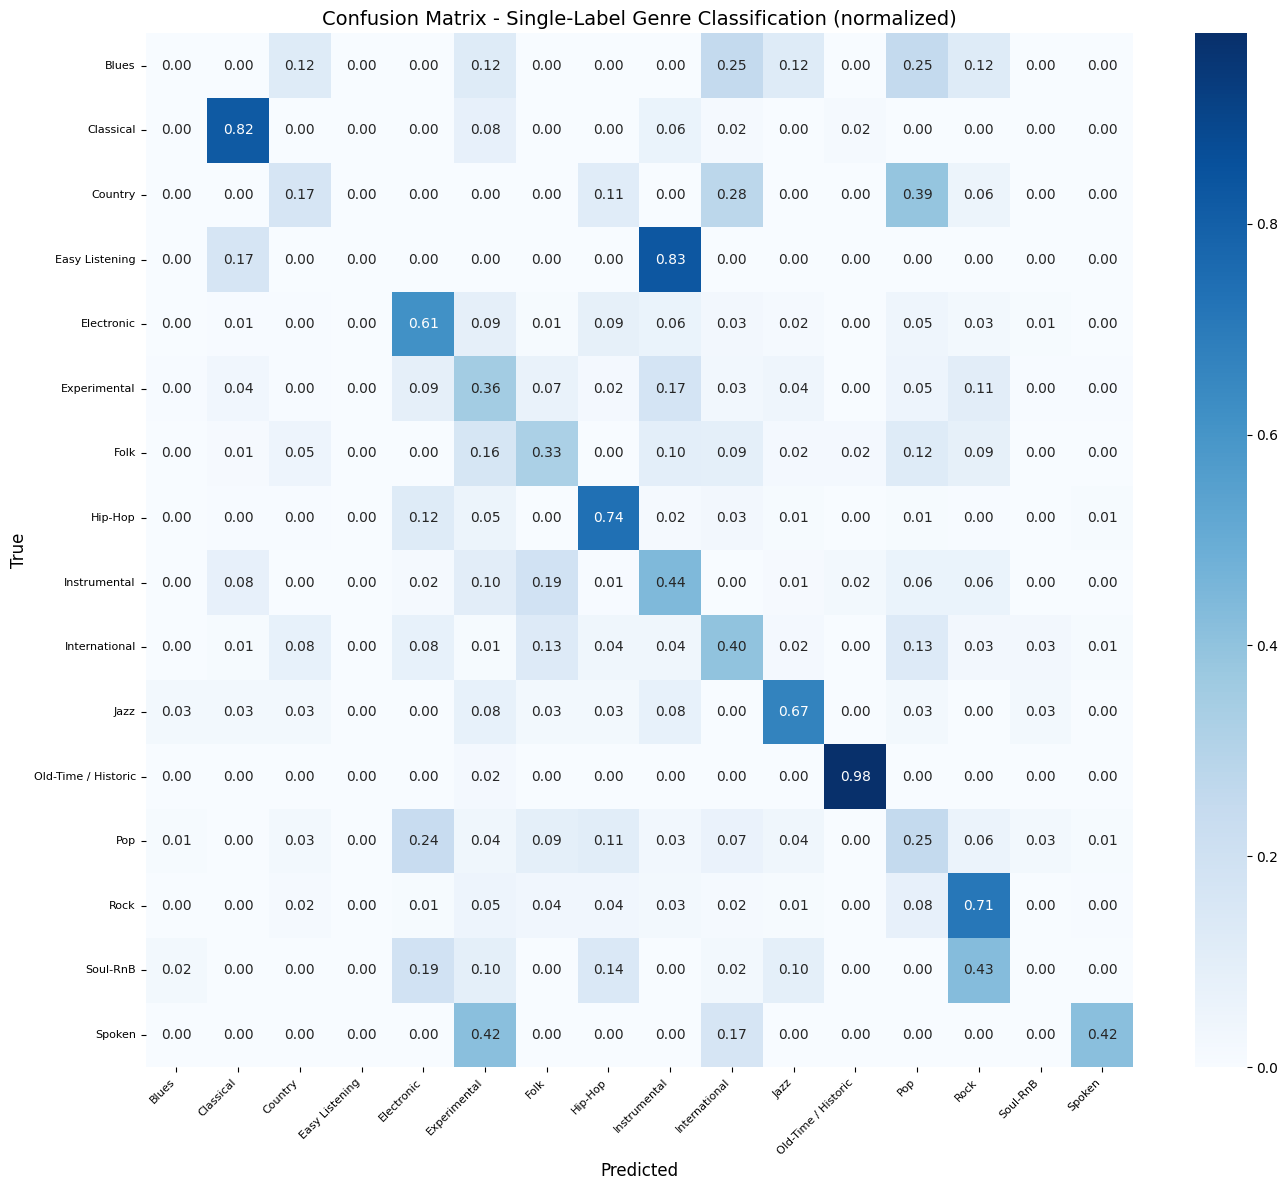

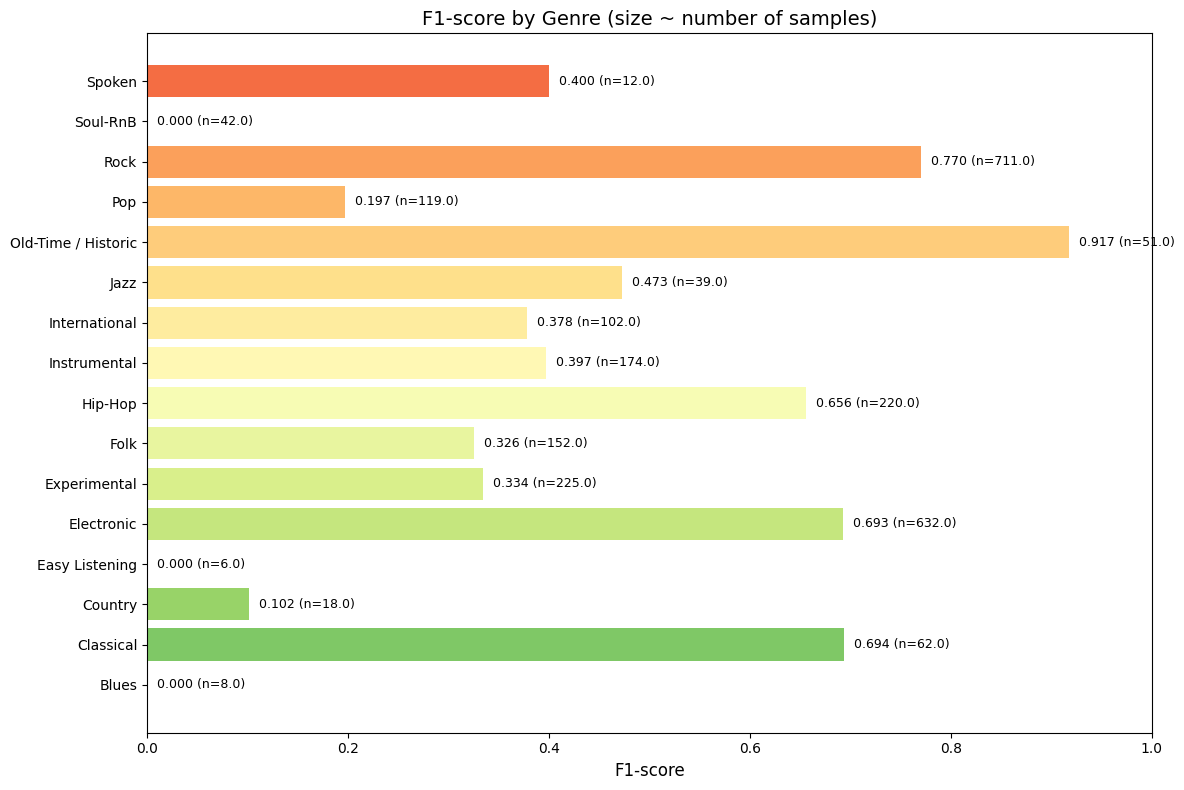

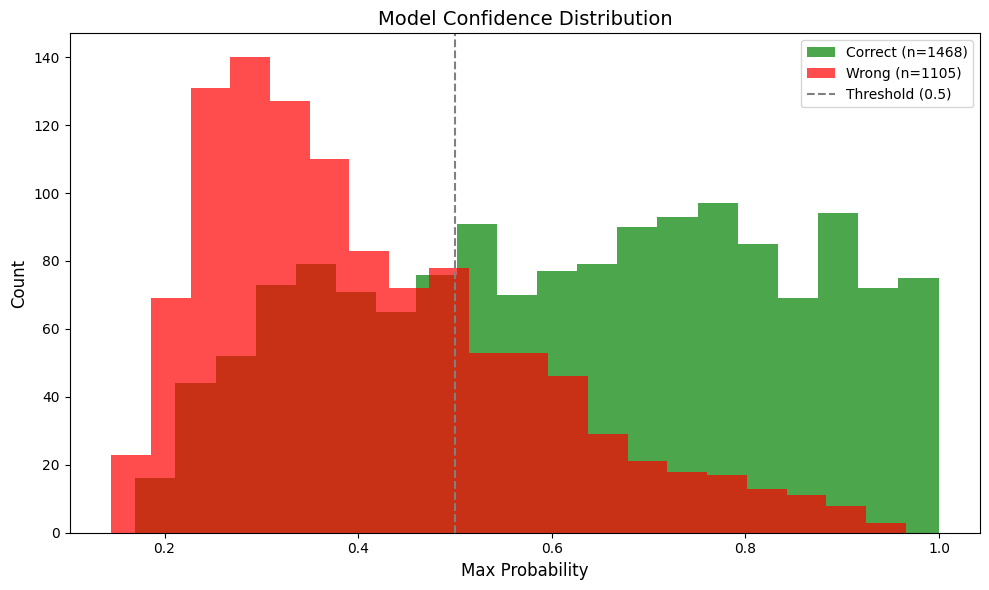

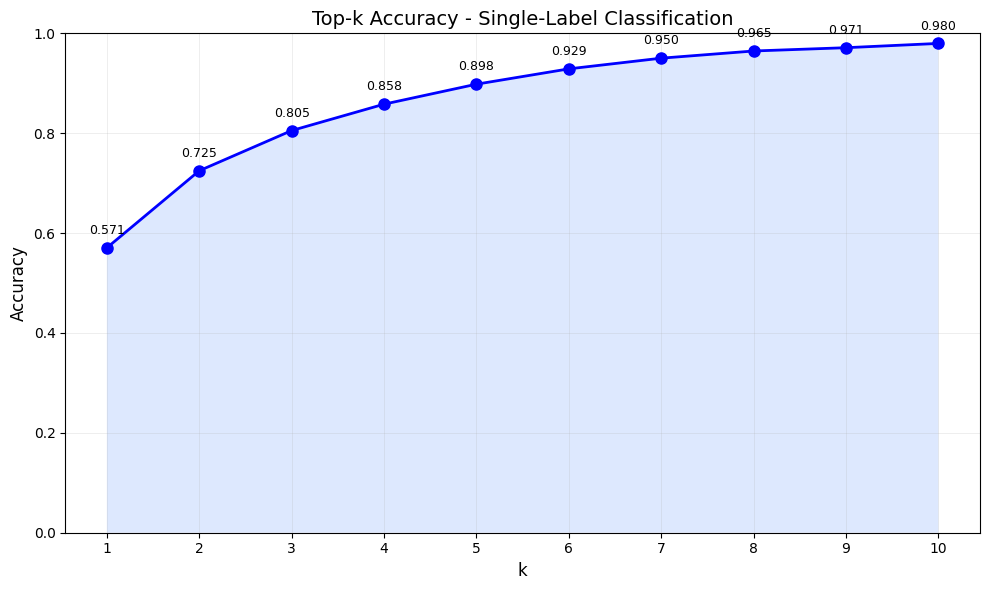

АНАЛИЗ РЕДКИХ ЖАНРОВ
Редкие жанры (≤ 50 треков): 6
  - Blues: 8 треков
  - Country: 18 треков
  - Easy Listening: 6 треков
  - Jazz: 39 треков
  - Soul-RnB: 42 треков
  - Spoken: 12 треков

F1 на редких жанрах: 0.3258

Частые жанры (> 50 треков): 10
F1 на частых жанрах: 0.6114

Разрыв: 0.2856


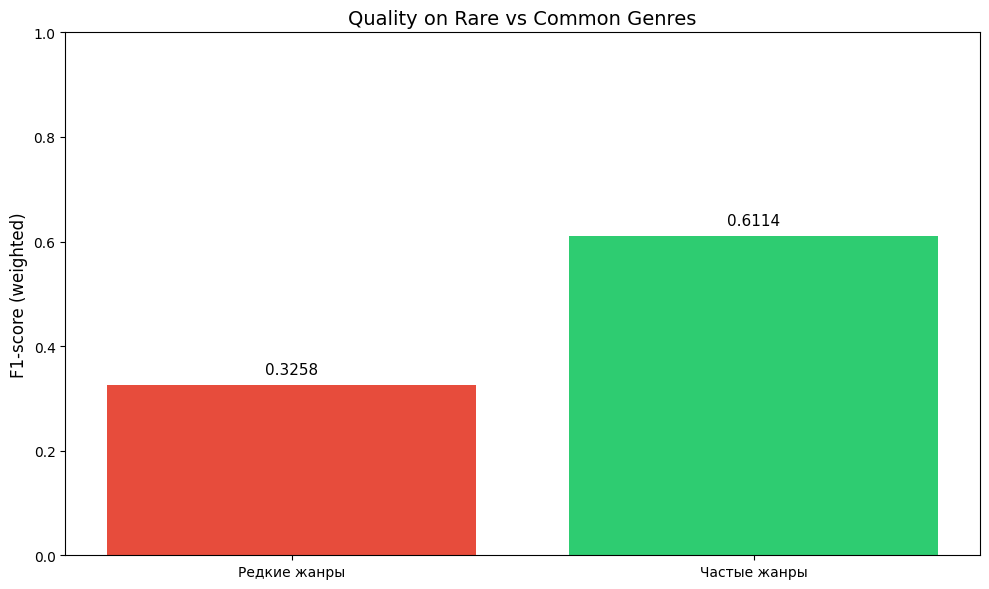

КОМПЛЕКСНЫЙ АНАЛИЗ МОДЕЛИ XGBOOST (MONO CLASSIFICATION)
Accuracy:          0.5705
F1-macro:          0.3960
F1-weighted:       0.5832
F1-micro:          0.5705
----------------------------------------------------------------------
Top-1 Accuracy:    0.5705
Top-3 Accuracy:    0.8053
Top-5 Accuracy:    0.8982
----------------------------------------------------------------------
Composite Score:   0.5972
ROC-AUC (ovo):     0.8525507341346491
----------------------------------------------------------------------
Ошибок:            1105 (42.95%)
Уверенность (прав.): 0.623
Уверенность (ошиб.): 0.413
Разрыв уверенности:  0.210
----------------------------------------------------------------------

Топ-10 частых ошибок (жанр → предсказание):
  Rock                 → Pop                 : 59 раз
  Electronic           → Experimental        : 57 раз
  Electronic           → Hip-Hop             : 55 раз
  Electronic           → Instrumental        : 41 раз
  Experimental         → Instrumental  

In [12]:
from src.training.analyzer import ModelAnalyzer

print("=" * 60)
print("ТЕСТИРОВАНИЕ ModelAnalyzer")
print("=" * 60)

analyzer = ModelAnalyzer(loaded_model, genre_names)

print("\n🔍 Анализ предсказаний...")
analysis = analyzer.analyze_predictions(X_test, y_test)

analyzer.print_analysis_report(analysis)

print("\n✅ Графики сохранены в:", paths.xgboost_mono_plots_dir)